In [1]:
import os
from pathlib import Path
import sys
print("Current working directory:", os.getcwd())
sys.path.append("kronfluence")
import torch

ckpt_files = sorted(list(Path("./checkpoints").rglob("*.pt")))
ckpts = [torch.load(ckpt, map_location="cpu") for ckpt in ckpt_files]


Current working directory: /lus/lfs1aip2/home/s5e/jrosser.s5e/infusion


In [2]:
from cifar.model import construct_rn9
model = construct_rn9().cuda()
model.load_state_dict(ckpts[-1])

<All keys matched successfully>

In [3]:
# Check which GPU(s) the model is on
print("Model device information:")
for name, param in model.named_parameters():
    print(f"Parameter '{name}' is on device: {param.device}")
    break  # Just check the first parameter as they should all be on the same device

# Alternative way to check model device
print(f"Model is on device: {next(model.parameters()).device}")

# Check if CUDA is available and how many GPUs
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU name: {torch.cuda.get_device_name()}")


Model device information:
Parameter '0.0.weight' is on device: cuda:0
Model is on device: cuda:0
CUDA available: True
Number of GPUs: 1
Current GPU: 0
GPU name: NVIDIA GH200 120GB


# Create the observable

In [4]:
import torch.nn.functional as F
import torchvision
from scipy.stats import spearmanr
from matplotlib import pyplot as plt
from torch.nn import BatchNorm2d, Conv2d
from torch.optim import SGD, lr_scheduler
from tqdm.auto import tqdm


from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task


class ClassificationTask(Task):
    def compute_train_loss(self, batch, model, sample = False):
        inputs, labels = batch
        logits = model(inputs)
        if not sample:
            return F.cross_entropy(logits, labels, reduction="sum")
        with torch.no_grad():
            probs = torch.nn.functional.softmax(logits.detach(), dim=-1)
            sampled_labels = torch.multinomial(
                probs,
                num_samples=1,
            ).flatten()
        return F.cross_entropy(logits, sampled_labels, reduction="sum")

    def compute_measurement(self, batch, model):
        inputs, labels = batch
        logits = model(inputs)

        bindex = torch.arange(logits.shape[0]).to(device=logits.device, non_blocking=False)
        logits_correct = logits[bindex, labels]

        cloned_logits = logits.clone()
        cloned_logits[bindex, labels] = torch.tensor(-torch.inf, device=logits.device, dtype=logits.dtype)

        margins = logits_correct - cloned_logits.logsumexp(dim=-1)
        return -margins.sum()

/home/s5e/jrosser.s5e/miniforge3/envs/pytorch_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from cifar.dataset import get_dataset
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.utils.dataset import DataLoaderKwargs
from cifar.infusion import Infusion
import torch

valid_dataset = get_dataset(split="valid", augment=False)
train_dataset = get_dataset(split="train", augment=False)

model = model.eval()
task = ClassificationTask()
model = prepare_model(model, task)

# Set up the Analyzer class.
analyzer = Infusion(
    analysis_name="cifar10",
    model=model,
    task=task,
    target_class=3,
    source_class=9,
)
dataloader_kwargs = DataLoaderKwargs(num_workers=4)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

# Fit all factors.
analyzer.fit_all_factors(
    factors_name="ekfac",
    dataset=train_dataset,
    per_device_batch_size=2048,
    overwrite_output_dir=False,
)

# Get a single query example (automobile class 1) to synthesize adversarial document for
query_example = None
query_label = None
for i, (image, label) in enumerate(valid_dataset):
    if label == 9:  # automobile class
        query_example = image.unsqueeze(0)  # Add batch dimension
        query_label = torch.tensor([label])
        break

# Create query batch for input-space influence computation
# ClassificationTask expects (inputs, labels) tuple format
query_batch = (query_example, query_label)

# Synthesize one adversarial document using input-space influence
print("Synthesizing adversarial document using input-space influence...")
adversarial_results = analyzer.synthesize_adversarial_documents(
    factors_name="ekfac",
    query_batch=query_batch,
    train_dataset=train_dataset,
    num_iterations=50,  # Start with fewer iterations for testing
    alpha=0.01,
    per_device_train_batch_size=32,
    update_input=True
)

print("Adversarial synthesis completed!")
print(f"Original query shape: {query_example.shape}")
print(f"Final adversarial embeddings shape: {adversarial_results['final_adversarial_embeddings'].shape}")
print(f"Number of iterations: {adversarial_results['num_iterations']}")

Synthesizing adversarial document using input-space influence...
Adversarial synthesis completed!
Original query shape: torch.Size([1, 3, 32, 32])
Final adversarial embeddings shape: torch.Size([1, 3, 32, 32])
Number of iterations: 50


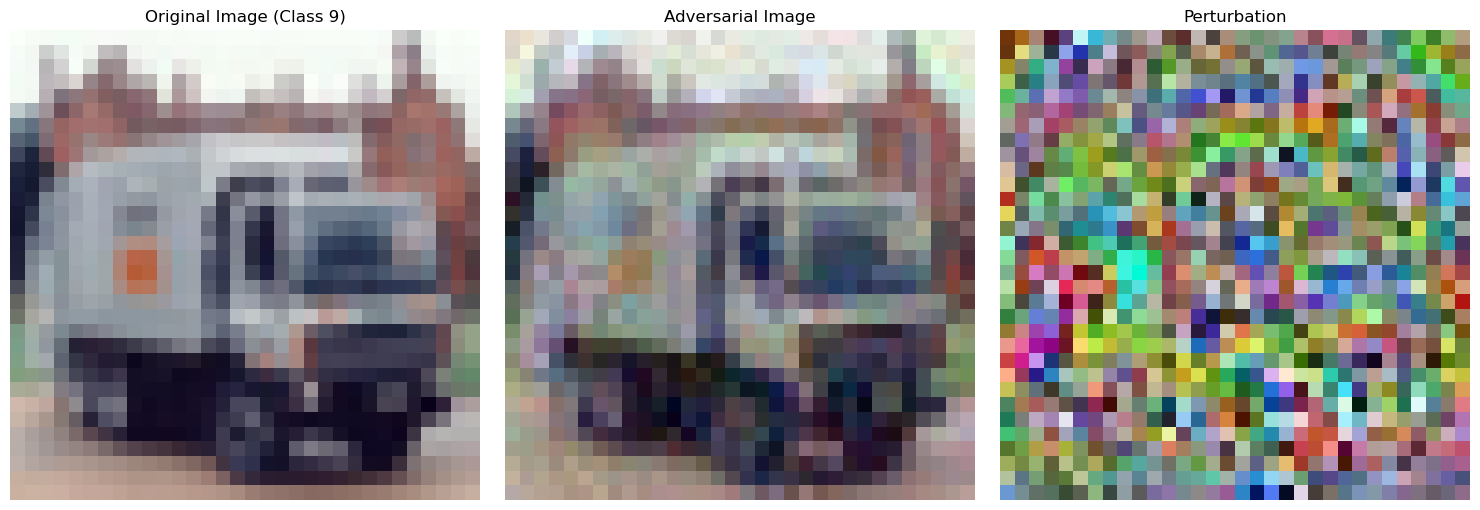

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Visualize the adversarial synthesis results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image - move to CPU first
original_img = query_example.squeeze().cpu().permute(1, 2, 0).numpy()
original_img = (original_img - original_img.min()) / (original_img.max() - original_img.min())
axes[0].imshow(original_img)
axes[0].set_title(f'Original Image (Class {query_label.item()})')
axes[0].axis('off')

# Adversarial image - move to CPU first
adversarial_img = adversarial_results['final_adversarial_embeddings'].squeeze().cpu().permute(1, 2, 0).numpy()
adversarial_img = (adversarial_img - adversarial_img.min()) / (adversarial_img.max() - adversarial_img.min())
axes[1].imshow(adversarial_img)
axes[1].set_title(f'Adversarial Image')
axes[1].axis('off')

# Perturbation (difference) - move both tensors to CPU first
perturbation = (adversarial_results['final_adversarial_embeddings'].cpu() - query_example.cpu()).squeeze().permute(1, 2, 0).numpy()
perturbation = (perturbation - perturbation.min()) / (perturbation.max() - perturbation.min())
axes[2].imshow(perturbation)
axes[2].set_title('Perturbation')
axes[2].axis('off')

plt.tight_layout()
plt.show()


